In [ ]:
# Import necessary libraries
import numpy as np # For linear algebra and numerical operations
import pandas as pd # For data processing and reading CSV files
import matplotlib.pyplot as plt # For basic visualizations
import seaborn as sns # For more appealing visualizations
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/SCNSN_Project/'
# Load the training and test dat
train_df = pd.read_csv(f"{data_path}training.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Display the first 5 rows of the training data
print("Training Data Head:")
display(train_df.head())

print("\nData loaded successfully")

Training Data Head:


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b



Data loaded successfully


In [ ]:
# split the training se in features and labels
X_train = train_df.drop(columns=["EventId", "Weight", "Label"])
y_train = train_df["Label"]
weigth = train_df["Weight"]

Now I need to convert the label "b" and "s" into the integers 0 and 1, respectively.

In [ ]:
y_train.replace("b", 0, inplace=True)
y_train.replace("s", 1, inplace=True)

/tmp/ipykernel_43306/3320523950.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_train.replace("s", 1, inplace=True)


In [ ]:
print(y_train)

0         1
1         0
2         0
3         0
4         0
         ..
249995    0
249996    0
249997    1
249998    0
249999    0
Name: Label, Length: 250000, dtype: int64


1. Data inspection:



In [ ]:
print(f"{X_train.shape}")
X_train.info()

(250000, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   DER_mass_MMC                 250000 non-null  float64
 1   DER_mass_transverse_met_lep  250000 non-null  float64
 2   DER_mass_vis                 250000 non-null  float64
 3   DER_pt_h                     250000 non-null  float64
 4   DER_deltaeta_jet_jet         250000 non-null  float64
 5   DER_mass_jet_jet             250000 non-null  float64
 6   DER_prodeta_jet_jet          250000 non-null  float64
 7   DER_deltar_tau_lep           250000 non-null  float64
 8   DER_pt_tot                   250000 non-null  float64
 9   DER_sum_pt                   250000 non-null  float64
 10  DER_pt_ratio_lep_tau         250000 non-null  float64
 11  DER_met_phi_centrality       250000 non-null  float64
 12  DER_lep_eta_centrality       250000 non-null 

In [ ]:
print(f"{y_train.shape}")
y_train.info()

(250000,)
<class 'pandas.core.series.Series'>
RangeIndex: 250000 entries, 0 to 249999
Series name: Label
Non-Null Count   Dtype
--------------   -----
250000 non-null  int64
dtypes: int64(1)
memory usage: 1.9 MB


In [ ]:
print("\nTraining Data Description:")
display(X_train.describe())


Training Data Description:


,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,-49.023079,49.239819,81.181982,57.895962,-708.420675,-601.237051,-709.356603,2.373100,18.917332,158.432217,...,-0.010119,209.797178,0.979176,-348.329567,-399.254314,-399.259788,-692.381204,-709.121609,-709.118631,73.064591
std,406.345647,35.344886,40.828691,63.655682,454.480565,657.972302,453.019877,0.782911,22.273494,115.706115,...,1.812223,126.499506,0.977426,532.962789,489.338286,489.333883,479.875496,453.384624,453.389017,98.015662
min,-999.000000,0.000000,6.329000,0.000000,-999.000000,-999.000000,-999.000000,0.208000,0.000000,46.104000,...,-3.142000,13.678000,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000
25%,78.100750,19.241000,59.388750,14.068750,-999.000000,-999.000000,-999.000000,1.810000,2.841000,77.550000,...,-1.575000,123.017500,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-0.000000
50%,105.012000,46.524000,73.752000,38.467500,-999.000000,-999.000000,-999.000000,2.491500,12.315500,120.664500,...,-0.024000,179.739000,1.000000,38.960000,-1.872000,-2.093000,-999.000000,-999.000000,-999.000000,40.512500
75%,130.606250,73.598000,92.259000,79.169000,0.490000,83.446000,-4.593000,2.961000,27.591000,200.478250,...,1.561000,263.379250,2.000000,75.349000,0.433000,0.503000,33.703000,-2.457000,-2.275000,109.933750
max,1192.026000,690.075000,1349.351000,2834.999000,8.503000,4974.979000,16.690000,5.684000,2834.999000,1852.462000,...,3.142000,2003.976000,3.000000,1120.573000,4.499000,3.141000,721.456000,4.500000,3.142000,1633.433000


Check the distribution of bakcground vs signal events.

In [ ]:
print("\nTarget Label Distribution:")
print(y_train.value_counts())


Target Label Distribution:
Label
0    164333
1     85667
Name: count, dtype: int64


In here handle the -999.0 by repling them with "nan", so that they do not affect the statistics for that column. Then, analyse the percentage of nan values per feature.

In [ ]:
X_train.replace(-999.0, np.nan, inplace=True)

#check the amount of missing values

missing_percent = X_train.isna().mean() * 100

# ordinati dal più “problematico” al meno
missing_percent = missing_percent.sort_values(ascending=False)

print(missing_percent)

DER_deltaeta_jet_jet           70.9828
DER_mass_jet_jet               70.9828
DER_lep_eta_centrality         70.9828
DER_prodeta_jet_jet            70.9828
PRI_jet_subleading_pt          70.9828
PRI_jet_subleading_phi         70.9828
PRI_jet_subleading_eta         70.9828
PRI_jet_leading_pt             39.9652
PRI_jet_leading_eta            39.9652
PRI_jet_leading_phi            39.9652
DER_mass_MMC                   15.2456
DER_pt_h                        0.0000
DER_mass_vis                    0.0000
DER_mass_transverse_met_lep     0.0000
PRI_tau_pt                      0.0000
DER_met_phi_centrality          0.0000
DER_pt_ratio_lep_tau            0.0000
DER_sum_pt                      0.0000
DER_deltar_tau_lep              0.0000
DER_pt_tot                      0.0000
PRI_tau_eta                     0.0000
PRI_tau_phi                     0.0000
PRI_met_sumet                   0.0000
PRI_met_phi                     0.0000
PRI_met                         0.0000
PRI_lep_phi              

In [ ]:
X_tr, X_test, y_tr, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

Now we substitue nan with values distributed according to the median of that features - the higher the number of nuns, the higher th number of fake data. At this point I am also going to split the dataset into training and validation set; after that, we are ready to proceed with EDA and feature engineering.

In [ ]:
X_tr = X_tr.fillna(X_tr.median(numeric_only=True))
X_test = X_test.fillna(X_test.median(numeric_only=True))


Now let's analyse the distribution of some features - first with the full dataset, secondly by separating background events from signal events.

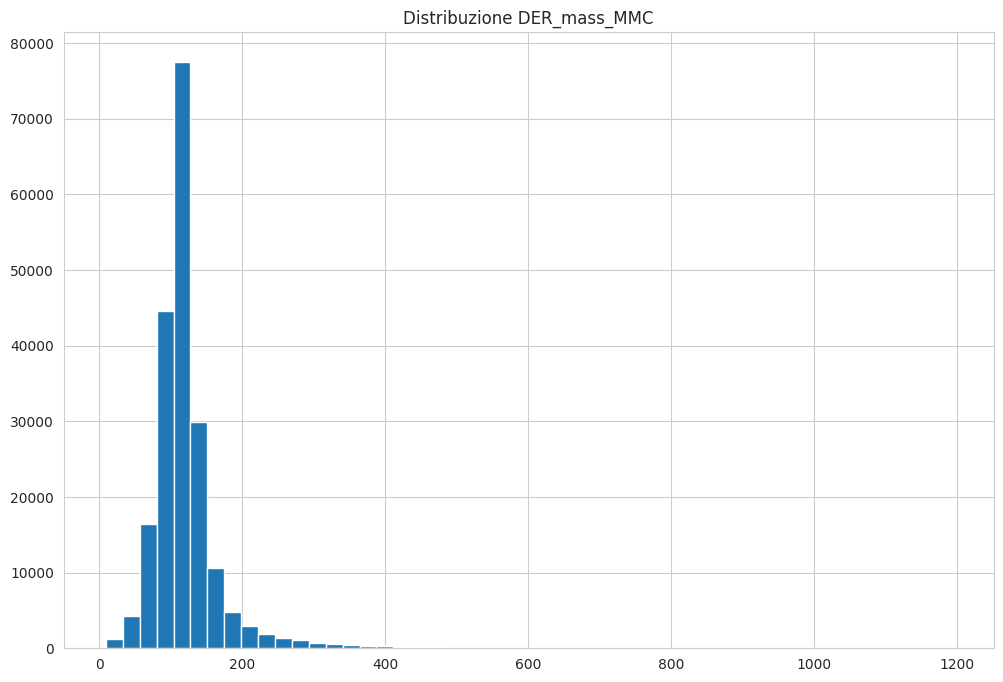

In [ ]:
X_tr["DER_mass_MMC"].hist(bins=50)
plt.title("Distribuzione DER_mass_MMC")
plt.show()

In [ ]:
signal = X_tr[y_tr== 1]
background = X_tr[y_tr == 0]

In [ ]:
# function to calculate mean separation
def mean_separation_xy(X, y, feature):
    signal = X[y == 1][feature].dropna()
    background = X[y == 0][feature].dropna()

    return abs(signal.mean() - background.mean()) / (signal.std() + background.std())

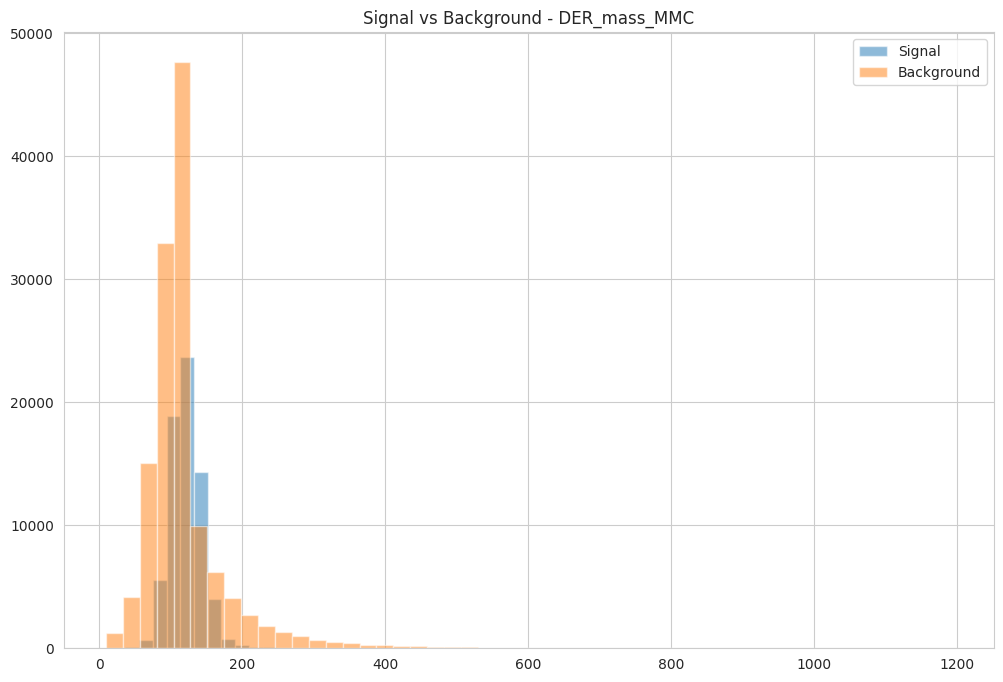

Mean separation - DER_mass_MMC:
0.03318562918180246


In [ ]:
plt.hist(signal["DER_mass_MMC"], bins=50, alpha=0.5, label="Signal")
plt.hist(background["DER_mass_MMC"], bins=50, alpha=0.5, label="Background")

plt.legend()
plt.title("Signal vs Background - DER_mass_MMC")
plt.show()

print("Mean separation - DER_mass_MMC:")
print(mean_separation_xy(X_tr, y_tr, "DER_mass_MMC"))

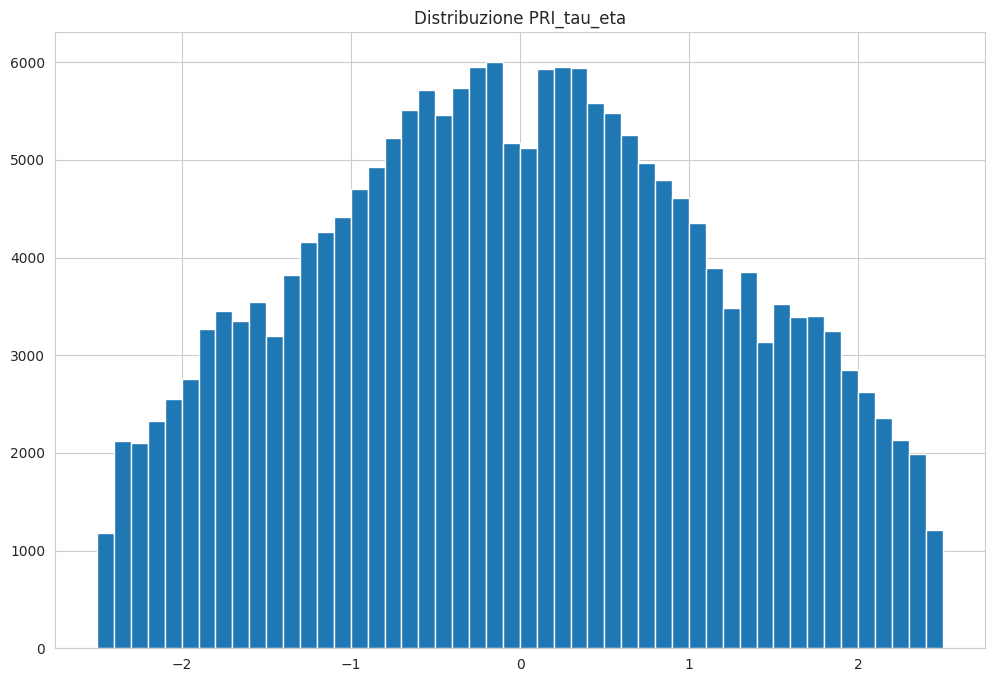

In [ ]:
X_tr["PRI_tau_eta"].hist(bins=50)
plt.title("Distribuzione PRI_tau_eta")
plt.show()

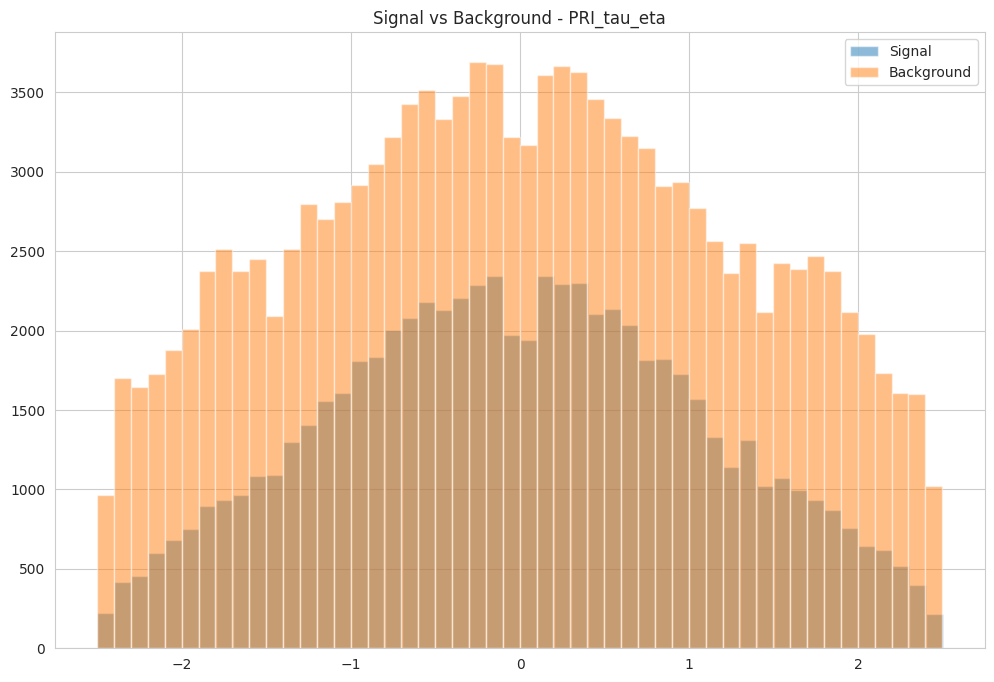

Mean separation -PRI_tau_eta:
0.002366516233240738
None


In [ ]:
plt.hist(signal["PRI_tau_eta"], bins=50, alpha=0.5, label="Signal")
plt.hist(background["PRI_tau_eta"], bins=50, alpha=0.5, label="Background")

plt.legend()
plt.title("Signal vs Background - PRI_tau_eta")
plt.show()

print("Mean separation -PRI_tau_eta:")
print(print(mean_separation_xy(X_tr, y_tr, "PRI_tau_eta")))

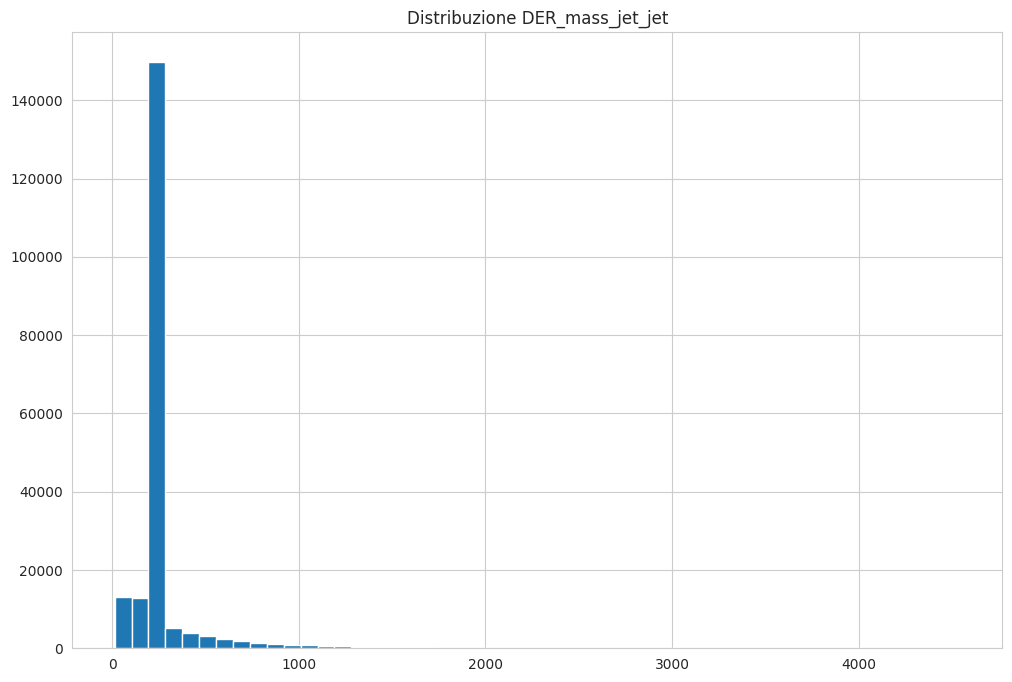

In [ ]:
X_tr["DER_mass_jet_jet"].hist(bins=50)
plt.title("Distribuzione DER_mass_jet_jet")
plt.show()

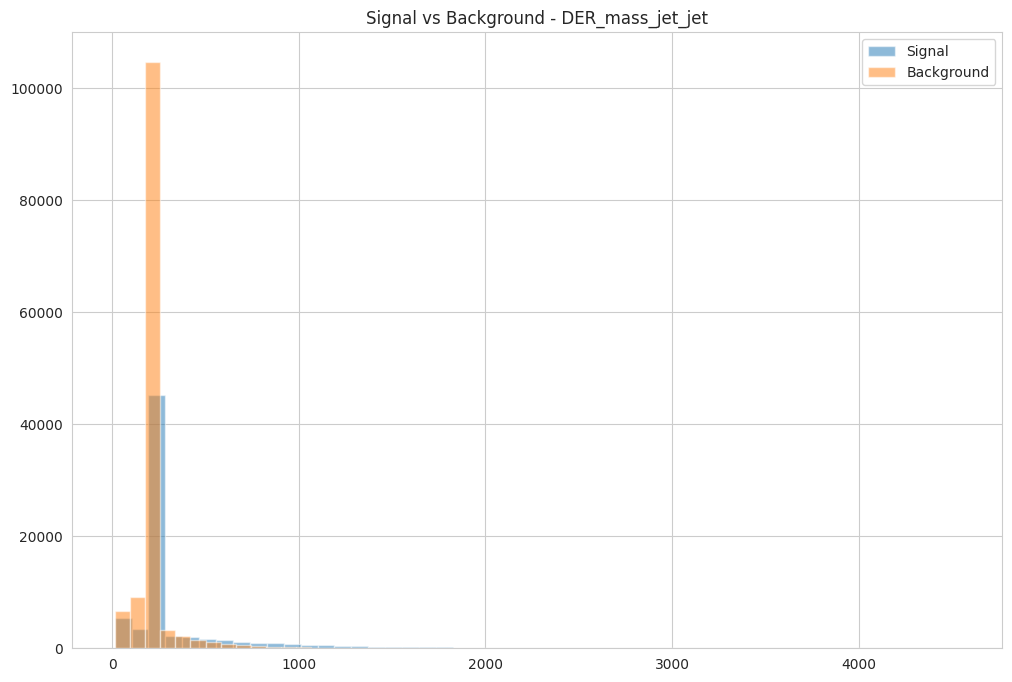

Mean separation - DER_mass_jet_jet:
0.21981078255275838


In [ ]:
plt.hist(signal["DER_mass_jet_jet"], bins=50, alpha=0.5, label="Signal")
plt.hist(background["DER_mass_jet_jet"], bins=50, alpha=0.5, label="Background")

plt.legend()
plt.title("Signal vs Background - DER_mass_jet_jet")
plt.show()

print("Mean separation - DER_mass_jet_jet:")
print(mean_separation_xy(X_tr, y_tr, "DER_mass_jet_jet"))

In [ ]:
# print the mean_separation for all the features
for feature in X_tr.columns:
  mean_separation = mean_separation_xy(X_tr, y_tr, feature)
  print(f"Mean separation - {feature}: {mean_separation}")

Mean separation - DER_mass_MMC: 0.03318562918180246
Mean separation - DER_mass_transverse_met_lep: 0.4051706518219364
Mean separation - DER_mass_vis: 0.016666004407453
Mean separation - DER_pt_h: 0.19921392021430767
Mean separation - DER_deltaeta_jet_jet: 0.20701490370324563
Mean separation - DER_mass_jet_jet: 0.21981078255275838
Mean separation - DER_prodeta_jet_jet: 0.1858198118097831
Mean separation - DER_deltar_tau_lep: 0.014019549245120763
Mean separation - DER_pt_tot: 0.01799545606807257
Mean separation - DER_sum_pt: 0.16128667433652752
Mean separation - DER_pt_ratio_lep_tau: 0.2088810436066576
Mean separation - DER_met_phi_centrality: 0.29571297449189576
Mean separation - DER_lep_eta_centrality: 0.18042151983128446
Mean separation - PRI_tau_pt: 0.24610404317895956
Mean separation - PRI_tau_eta: 0.002366516233240738
Mean separation - PRI_tau_phi: 0.00487165024191727
Mean separation - PRI_lep_pt: 0.03175944713425138
Mean separation - PRI_lep_eta: 7.616304782063013e-05
Mean separat

Now I am going to define the binary classifier, using three different tools: the linear binary SGDC classifier, the non-linear Random Forest classifier, and a simple DNN. Then, I am going to compare the results obtain with these three models in order to elige the most performing one.

In [ ]:
# scale the dataset first; so that features lies between 0 and 1
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_tr)
X_test_scaled = scaler1.fit_transform(X_test)

In [ ]:
#Model 1: linear SGDC classifier
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=42)
sgd_clf.fit(X_train_scaled, y_tr)

SGDClassifier(loss='log_loss', random_state=42)

In [ ]:
%%time
# Model 2: Random Tree Forest
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

#rf_clf = RandomForestClassifier(random_state=42)

xgb_model = xgb.XGBClassifier(
    tree_method='hist',  # Algoritmo ottimizzato ad albero
    device='cuda',       # Forza l'utilizzo della GPU
    n_estimators=100
)

cv_split = KFold(n_splits=5, random_state=42, shuffle=True)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator= xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_tr, y_tr)

best_rf = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:15:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 5}
0.9078124828468264
CPU times: user 2.58 s, sys: 314 ms, total: 2.89 s
Wall time: 5min 2s


In [ ]:
# Model 3: DNN
from tensorflow.keras import models
from tensorflow.keras.layers import Dense

dnn = models.Sequential([
    Dense(64, activation='relu', input_shape=(X_tr.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
dnn.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy', 'AUC'])

In [ ]:
history_callback = dnn.fit(X_train_scaled, y_tr, epochs=5, batch_size=128, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - AUC: 0.8780 - accuracy: 0.8114 - loss: 0.4118 - val_AUC: 0.8979 - val_accuracy: 0.8296 - val_loss: 0.3794
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9000 - accuracy: 0.8324 - loss: 0.3751 - val_AUC: 0.9018 - val_accuracy: 0.8318 - val_loss: 0.3731
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.9037 - accuracy: 0.8356 - loss: 0.3681 - val_AUC: 0.9040 - val_accuracy: 0.8347 - val_loss: 0.3691
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9060 - accuracy: 0.8373 - loss: 0.3638 - val_AUC: 0.9036 - val_accuracy: 0.8344 - val_loss: 0.3686
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.9073 - accuracy: 0.8389 - loss: 0.3612 - val_AUC: 0.9062 - val_accuracy: 0.8371 - val_loss: 0.3635


<Axes: >

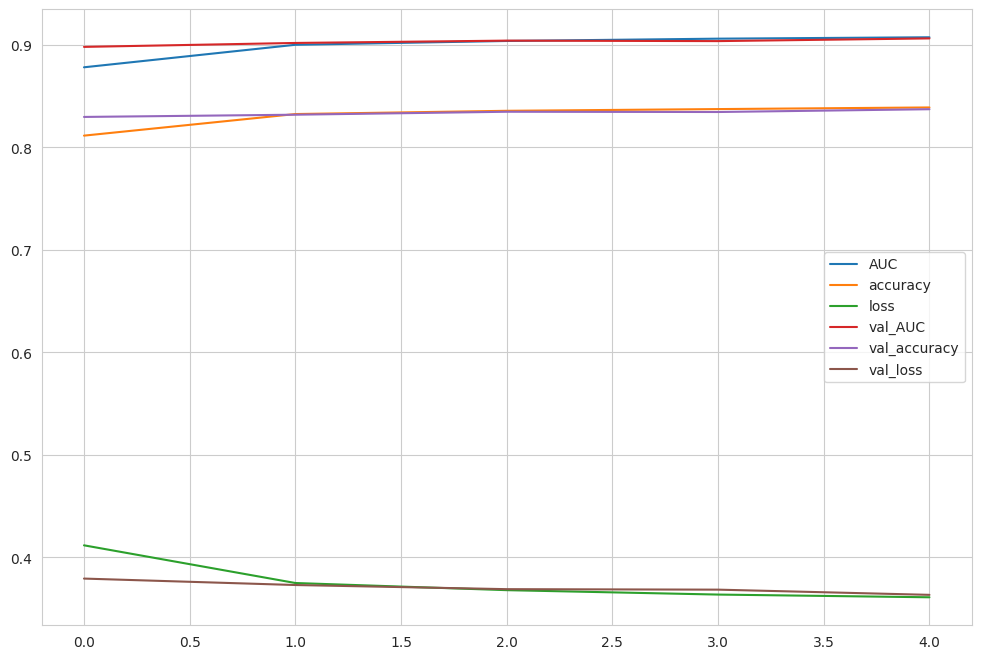

In [ ]:
pd.DataFrame(history_callback.history).plot()

In [ ]:
history_callback_1 = dnn.fit(X_train_scaled, y_tr, epochs=10, batch_size=128, validation_split=0.2)

In [ ]:
pd.DataFrame(history_callback_1.history).plot()

In [ ]:
#dnn.fit(X_train_scaled, y_tr, epochs=10, batch_size=128, validation_split=0.2)

Now we can evaluate the three models.

In [ ]:
# evaluation function

def evaluate_model(model, X, y, name="Model"):

    # predictions
    y_pred = model.predict(X)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
    else:
        # DNN case (Keras)
        y_score = model.predict(X).ravel()

    # --- predictions (class labels) ---
    if hasattr(model, "predict_proba") or hasattr(model, "decision_function"):
        y_pred = (y_score > 0.5).astype(int)
    else:
        y_pred = (y_score > 0.5).astype(int)

    # metrics
    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_score)
    }

    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    # ROC curve
    fpr, tpr, _ = roc_curve(y, y_score)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['ROC-AUC']:.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    # --- Confusion matrix ---
    ConfusionMatrixDisplay.from_predictions(y, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    return metrics



=== SGD ===
Accuracy: 0.7502
Precision: 0.6671
Recall: 0.5236
F1-score: 0.5867
ROC-AUC: 0.8114


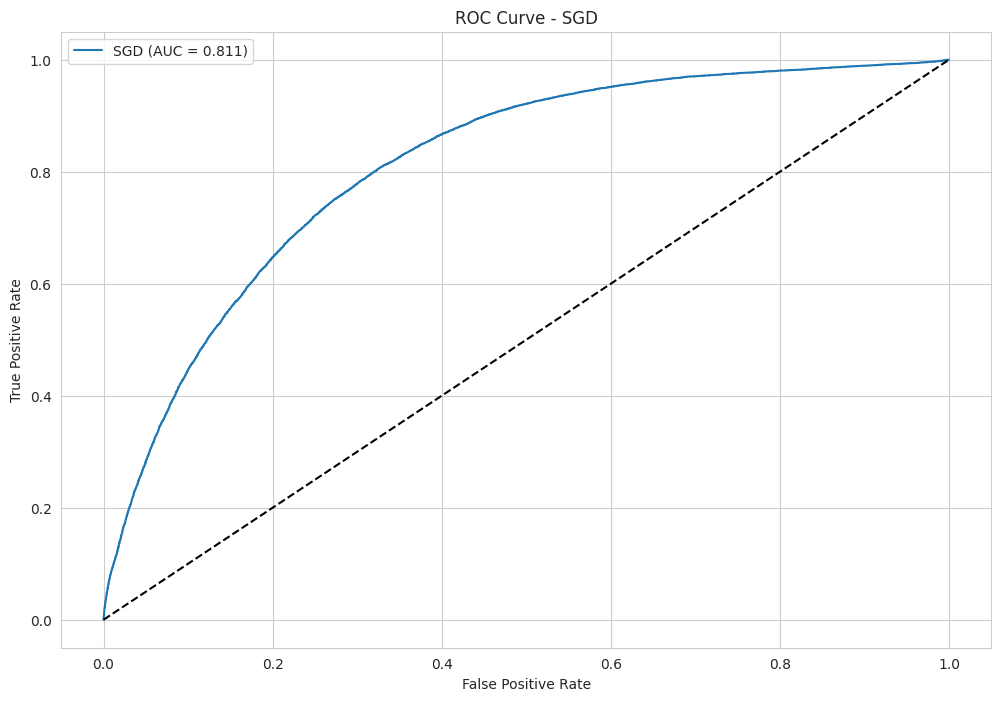

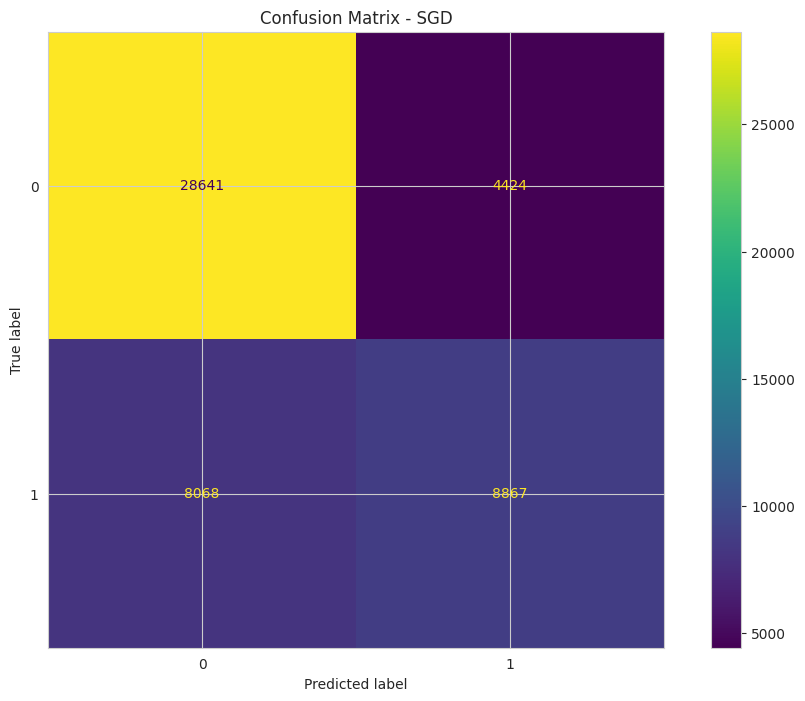

In [ ]:
# SGDC Classifier
sgd_metrics = evaluate_model(
    sgd_clf,
    X_test_scaled,
    y_test,
    name="SGD"
)


=== XGBoost ===
Accuracy: 0.8393
Precision: 0.7912
Recall: 0.7139
F1-score: 0.7506
ROC-AUC: 0.9087


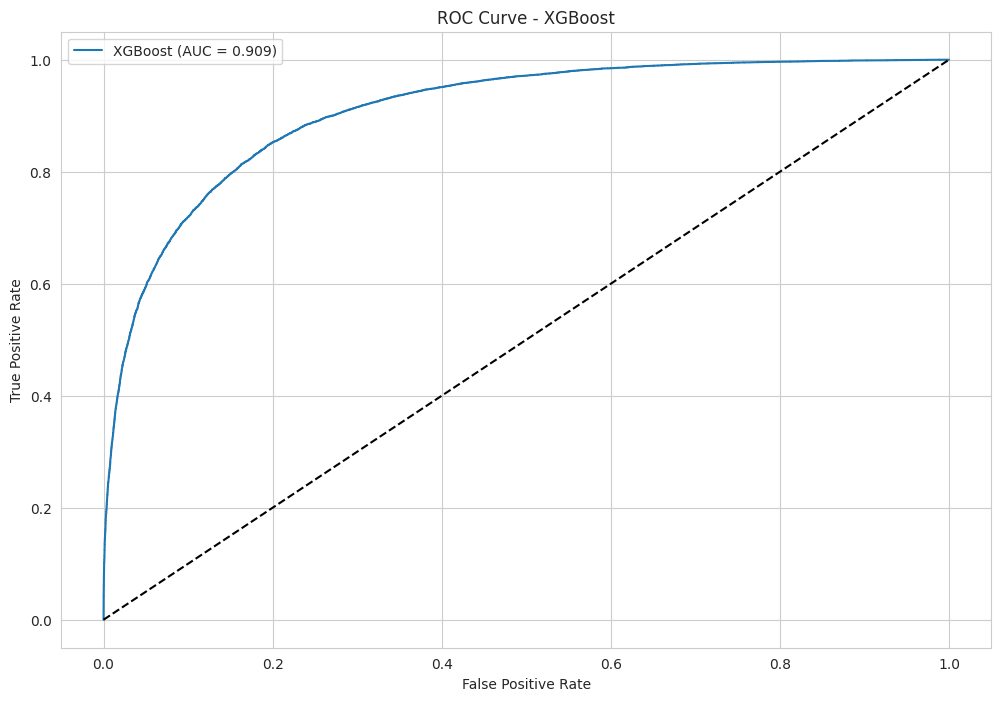

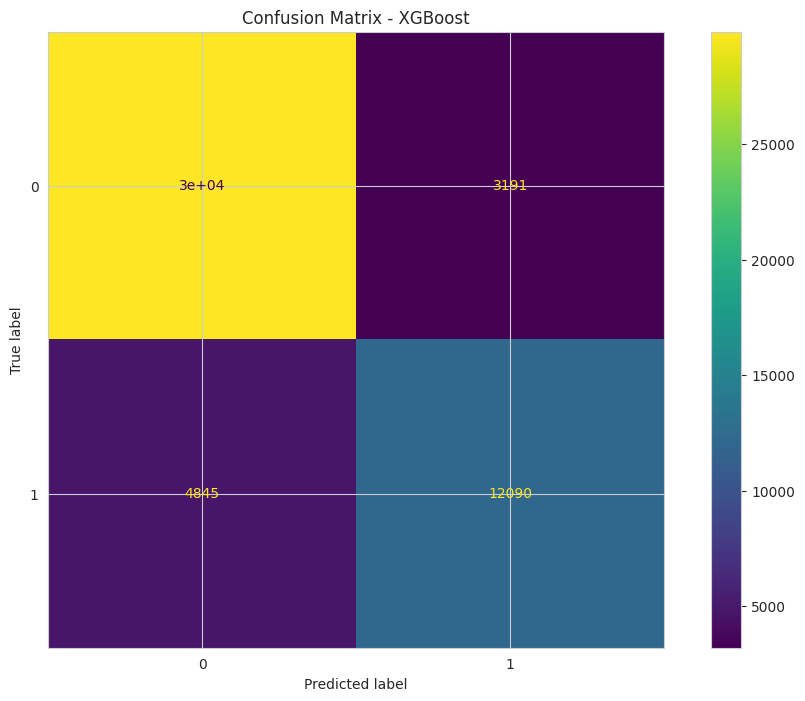

In [ ]:
# Xgboost mdel
xgb_metrics = evaluate_model(
    best_rf,
    X_test,
    y_test,
    name="XGBoost"
)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

=== DNN ===
Accuracy: 0.8371
Precision: 0.7906
Recall: 0.7059
F1-score: 0.7459
ROC-AUC: 0.9071


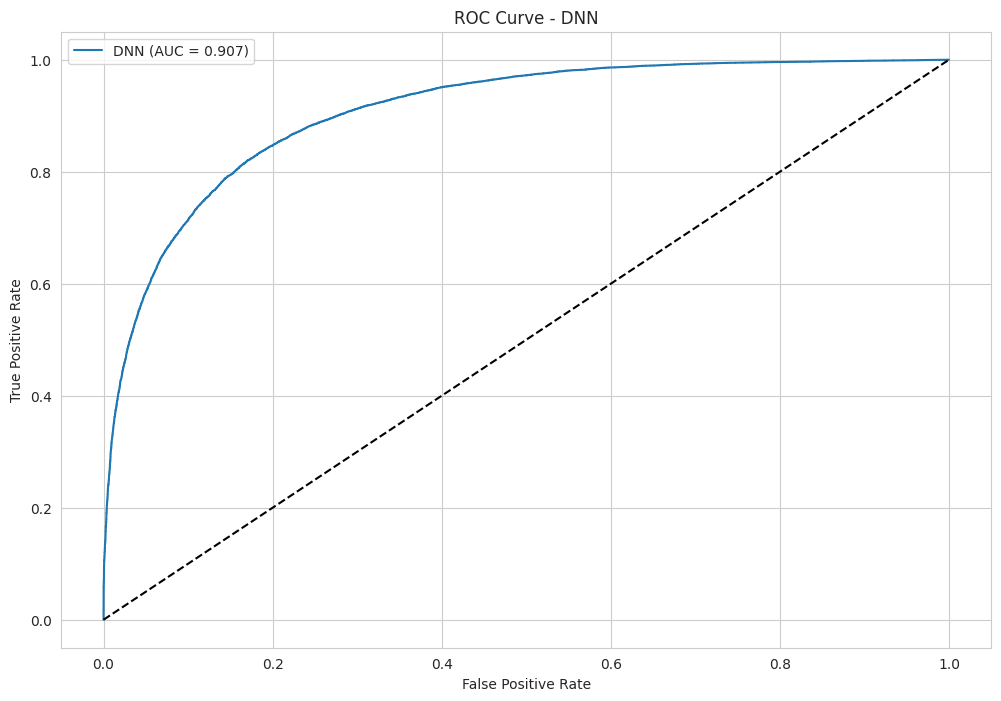

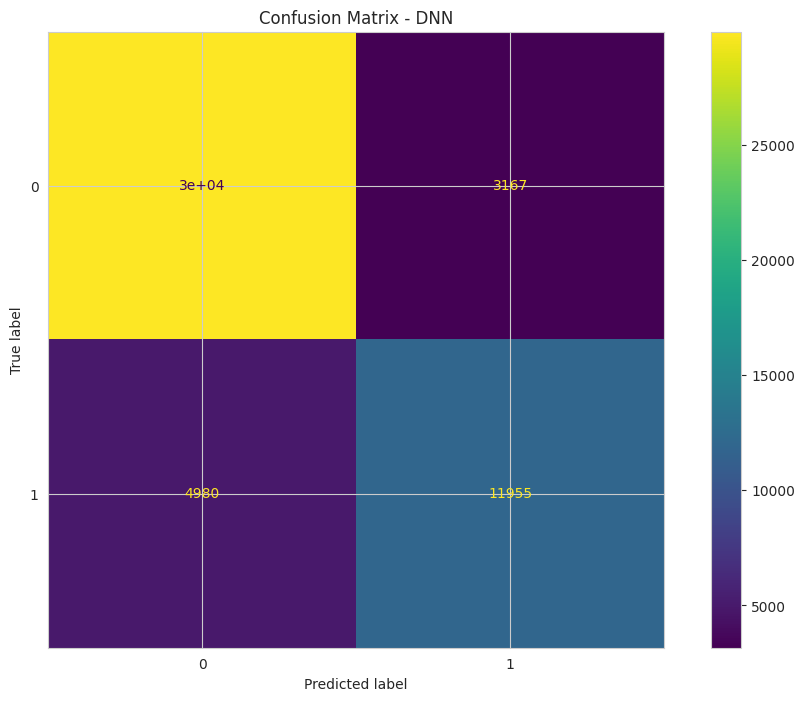

In [ ]:
# DNN
dnn_metrics = evaluate_model(
    dnn,
    X_test_scaled,
    y_test,
    name="DNN"
)

xGBoost won the competition! Now I can try to select some features and see if this can improve the performance

In [ ]:
# use mean separation
scores = {
    col: mean_separation_xy(X_tr, y_tr, col)
    for col in X_tr.columns
}

scores = pd.Series(scores).sort_values(ascending=False)

selected_features = scores[scores > 0.1].index

X_tr_2 = X_tr[selected_features]
X_test_2 = X_test[selected_features]

In [ ]:
%%time
# Model 2: XGBoost
import xgboost as xgb

xgb_model_2 = xgb.XGBClassifier(
    tree_method='hist',  # Algoritmo ottimizzato ad albero
    device='cuda',       # Forza l'utilizzo della GPU
    n_estimators=100
)

cv_split_2 = KFold(n_splits=5, random_state=42, shuffle=True)

param_dist_2 = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30]
}

random_search_2 = RandomizedSearchCV(
    estimator=xgb_model_2, # Changed estimator from xgb_model to xgb_model_2
    param_distributions=param_dist_2,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_2.fit(X_tr_2, y_tr)

best_rf_2 = random_search_2.best_estimator_

print(random_search_2.best_params_)
print(random_search_2.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'n_estimators': 100, 'max_depth': 5}
0.8460548571913372
CPU times: user 1.53 s, sys: 269 ms, total: 1.8 s
Wall time: 4min 43s



=== XGBoost ===
Accuracy: 0.7821
Precision: 0.7159
Recall: 0.5911
F1-score: 0.6476
ROC-AUC: 0.8467


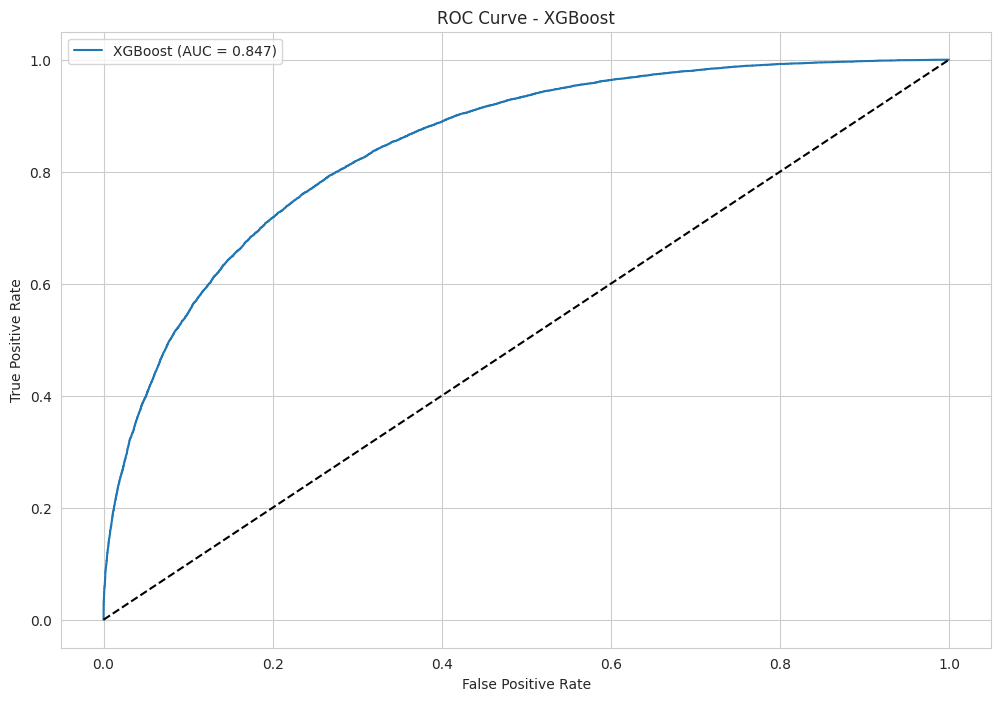

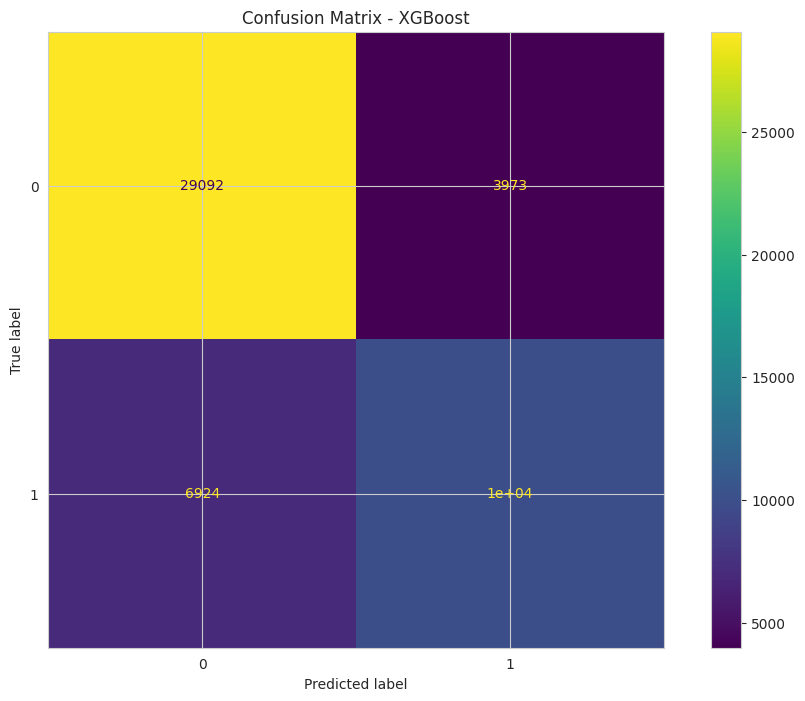

In [ ]:
# Xgboost mdel
xgb_metrics_2 = evaluate_model(
    best_rf_2,
    X_test_2,
    y_test,
    name="XGBoost"
)

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

X_sample = X_tr.sample(n=20000, random_state=42)
y_sample = y_tr.loc[X_sample.index]

# mutual information
print("Mutual Information score (relazioni...")
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

# show results
df_mi = pd.DataFrame({
    'Feature': X_tr.columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print("\n in order:")
print(df_mi.head(10))

#top k feature selection
non_linear_selector = SelectKBest(score_func=mutual_info_classif, k=10)

# fit
non_linear_selector.fit(X_sample, y_sample)

# keep only selected feature
X_tr_3 = non_linear_selector.transform(X_tr)
X_test_3 = non_linear_selector.transform(X_test)

# show selected feature
saved_feature = X_tr.columns[non_linear_selector.get_support()]
print(f"\nFeature selezionate ({len(saved_feature)}): {list(saved_feature)}")


Mutual Information score (relazioni...

 in order:
                        Feature  MI_Score
0                  DER_mass_MMC  0.149193
1   DER_mass_transverse_met_lep  0.087067
2                  DER_mass_vis  0.076706
13                   PRI_tau_pt  0.046832
11       DER_met_phi_centrality  0.044132
4          DER_deltaeta_jet_jet  0.036932
10         DER_pt_ratio_lep_tau  0.035170
6           DER_prodeta_jet_jet  0.032858
5              DER_mass_jet_jet  0.030855
9                    DER_sum_pt  0.029070

Feature selezionate (10): ['DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_sum_pt', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'PRI_tau_pt']


In [ ]:
%%time
# Model 2: XGBoost
import xgboost as xgb

xgb_model_3 = xgb.XGBClassifier(
    tree_method='hist',  # Algoritmo ottimizzato ad albero
    device='cuda',       # Forza l'utilizzo della GPU
    n_estimators=100
)

cv_split_3 = KFold(n_splits=5, random_state=42, shuffle=True)

param_dist_3 = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30]
}

random_search_3 = RandomizedSearchCV(
    estimator=xgb_model_3, # Changed estimator from xgb_model to xgb_model_2
    param_distributions=param_dist_3,
    n_iter=20,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_3.fit(X_tr_3, y_tr)

best_rf_3 = random_search_3.best_estimator_

print(random_search_3.best_params_)
print(random_search_3.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'n_estimators': 100, 'max_depth': 5}
0.8978152997716454
CPU times: user 1.24 s, sys: 243 ms, total: 1.48 s
Wall time: 3min 55s



=== XGBoost ===
Accuracy: 0.8304
Precision: 0.7734
Recall: 0.7063
F1-score: 0.7383
ROC-AUC: 0.8963


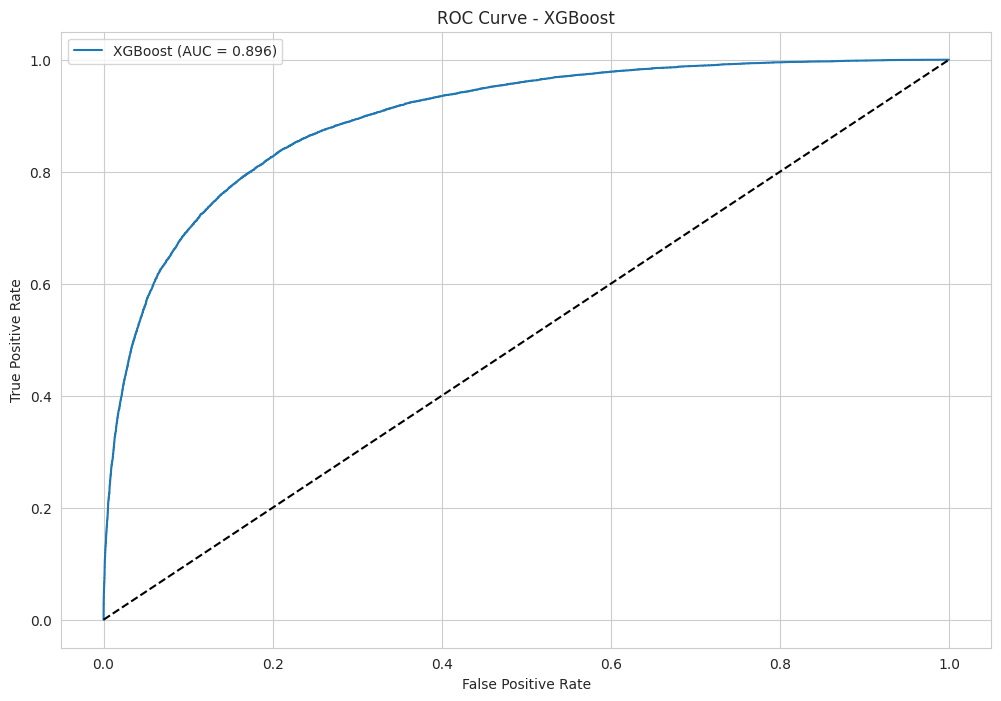

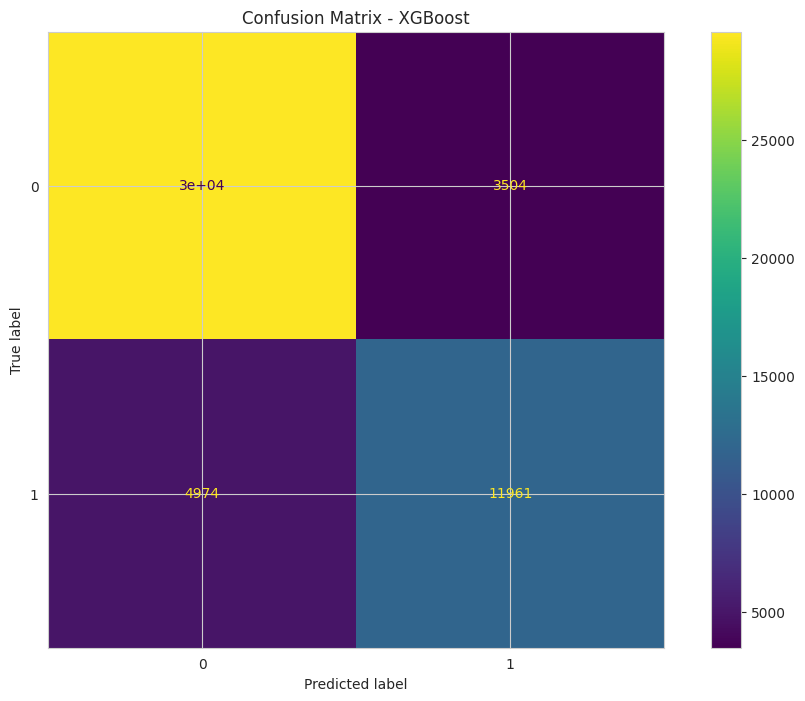

In [ ]:
xgb_metrics_3 = evaluate_model(
    best_rf_3,
    X_test_3,
    y_test,
    name="XGBoost"
)